# Fitting the simulation to the data

This notebook shows how simulation-derived universalization metrics and
scenario outcome metrics relate to average moral judgments, following the
regression approach used in Kwon et al. (CogSci 2023).

It is provided as an illustrative analysis for readers, not as the primary
statistical analysis for the new paper.

In [19]:
import pandas as pd
from build_utils import get_experimental_data, get_universalization_summary, get_outcome_metrics, build_design_matrix
from analysis_utils import plot_simple_regression, compare_models, fit_ols
from pathlib import Path

# Simulation run to use
RUN_LABEL = "joe_restore_FunctionalVPol_2026-02-12"

# Saving info
RUN_PREFIX = "joe"
SAVE_FOLDER = Path("figures/second_nerfed_simu_02-19")

# Columns used in analyses
OUTCOME_COLS = ["aggregate_welfare", "inequality", "cardinal_harm", "ordinal_harm_blind", "gini"]
UNIV_COLS = [f"univ_{c}" for c in OUTCOME_COLS]

## 1. Data loading and design matrix

We load:

- scenario-level outcome metrics (computed from scenario completion times),
- experimental judgments (`cross_cultural_pilot_summary.csv`),
- universalization metrics for the simulation run `RUN_LABEL`,

and combine them into a regression-ready design matrix.

In [20]:
# Outcome metrics
out = get_outcome_metrics(recompute=True) # set to True to rebuild from completion times

# Experimental judgments
xp_file = "country_agg_judgment.csv"
xp = get_experimental_data(xp_file)

# Universalization summary for this simulation run
univ = get_universalization_summary(run_label=RUN_LABEL, recompute=True) # set to True to rebuild from raw simulation data

# Regression-ready design matrix: one row per scenario
design = build_design_matrix(univ, out, xp)

Built 39 scenario outcome rows and saved to ../data/scenarios/outcome_metrics.csv
Processed 28 maps for run_label='joe_restore_FunctionalVPol_2026-02-12' and saved to ../data/simulations/joe_restore_FunctionalVPol_2026-02-12/processed
Built universalization summary for run_label='joe_restore_FunctionalVPol_2026-02-12' over 28 maps and saved to summary_universalization_metrics.csv


In [21]:
univ

,map,n_runs,order,info,reasoning,planning,planning_h_mult,planning_search_noise,univ_aggregate_welfare,univ_aggregate_welfare_sd,...,univ_cardinal_harm,univ_cardinal_harm_sd,univ_ordinal_harm_blind,univ_ordinal_harm_blind_sd,univ_gini,univ_gini_sd,mean,last,first,prop_finished
0,10esque,5,fixed,full,L1,astar,2.0,0.5,5.194805,0.0,...,0.0,0.0,0.0,0.0,-0.214286,0.000000e+00,NaN,NaN,NaN,0.0
1,7esque,5,fixed,full,L1,astar,2.0,0.5,5.688889,0.0,...,0.0,0.0,0.0,0.0,-0.169355,0.000000e+00,NaN,NaN,NaN,0.0
2,9esque,5,fixed,full,L1,astar,2.0,0.5,5.333333,0.0,...,0.0,0.0,0.0,0.0,-0.223790,3.103168e-17,NaN,NaN,NaN,0.0
3,maybe_4,5,fixed,full,L1,astar,2.0,0.5,5.581395,0.0,...,0.0,0.0,0.0,0.0,-0.181034,0.000000e+00,NaN,NaN,NaN,0.0
4,maybe_5,5,fixed,full,L1,astar,2.0,0.5,5.241379,0.0,...,0.0,0.0,0.0,0.0,-0.212838,3.103168e-17,NaN,NaN,NaN,0.0
5,maybe_6,5,fixed,full,L1,astar,2.0,0.5,5.960784,0.0,...,0.0,0.0,0.0,0.0,-0.141892,0.000000e+00,NaN,NaN,NaN,0.0
6,new_maybe_1,5,fixed,full,L1,astar,2.0,0.5,5.581395,0.0,...,0.0,0.0,0.0,0.0,-0.181034,0.000000e+00,NaN,NaN,NaN,0.0
7,new_maybe_2,5,fixed,full,L1,astar,2.0,0.5,5.636364,0.0,...,0.0,0.0,0.0,0.0,-0.175000,0.000000e+00,NaN,NaN,NaN,0.0
8,new_maybe_3,5,fixed,full,L1,astar,2.0,0.5,5.288136,0.0,...,0.0,0.0,0.0,0.0,-0.207237,0.000000e+00,NaN,NaN,NaN,0.0
9,new_maybe_4,5,fixed,full,L1,astar,2.0,0.5,6.142857,0.0,...,0.0,0.0,0.0,0.0,-0.125000,0.000000e+00,NaN,NaN,NaN,0.0


## 2. Outcome-only models

We first ask: among the outcome metrics derived directly from the line-cutting
scenarios, which combination best predicts average moral judgments?

We fit OLS models for all non-empty subsets of the outcome metrics and compare
them using BIC (and R², adjusted R²).

*Result (for this dataset):* the best outcome-only model is a simple regression
on **aggregate_welfare**.

In [22]:
summary_baseline = compare_models(
    design_df=design,
    predictors=OUTCOME_COLS,
    run_label=RUN_LABEL,
    dv="rating_mean"
)
summary_baseline.head() # Show best models sorted by BIC

,n_predictors,predictors,run_label,R2,adj_R2,AIC,BIC,n,predictors_full_name
0,1,AW,joe_restore_FunctionalVPol_2026-02-12,0.621276,0.611040,55.546449,58.873573,39,aggregate_welfare
6,2,AW+CH,joe_restore_FunctionalVPol_2026-02-12,0.625243,0.604423,57.135810,62.126495,39,aggregate_welfare+cardinal_harm
7,2,AW+OH,joe_restore_FunctionalVPol_2026-02-12,0.623575,0.602662,57.308981,62.299666,39,aggregate_welfare+ordinal_harm_blind
8,2,AW+Gini,joe_restore_FunctionalVPol_2026-02-12,0.622395,0.601416,57.431073,62.421758,39,aggregate_welfare+gini
5,2,AW+Ineq,joe_restore_FunctionalVPol_2026-02-12,0.622109,0.601115,57.460543,62.451228,39,aggregate_welfare+inequality


## 3. Adding universalization metrics from the simulation

Next, we test whether **universalization metrics** computed from the simulation
help explain additional variance in moral judgments.

We start from the baseline model with aggregate welfare (shown above to be the
best outcome-only model) and consider models that add one or more
universalization metrics.

*Result (for this dataset):*

- the best model uses one simulation-based predictor: **univ_aggregate_welfare**
  in addition to aggregate_welfare;
- compared to the aggregate-welfare-only baseline, this model shows a decrease
  in BIC of about 7 and an increase in R² of about 0.09.

In [23]:
summary_univ = compare_models(
    design_df=design,
    predictors=["aggregate_welfare"] + UNIV_COLS,
    run_label=RUN_LABEL,
    dv="rating_mean",
)
summary_univ.head() # Show best models sorted by BIC

,n_predictors,predictors,run_label,R2,adj_R2,AIC,BIC,n,predictors_full_name
0,1,AW,joe_restore_FunctionalVPol_2026-02-12,0.621276,0.611040,55.546449,58.873573,39,aggregate_welfare
8,2,AW+U_CH,joe_restore_FunctionalVPol_2026-02-12,0.621276,0.611040,55.546449,58.873573,39,aggregate_welfare+univ_cardinal_harm
22,3,AW+U_AW+U_CH,joe_restore_FunctionalVPol_2026-02-12,0.643882,0.624098,55.146110,60.136795,39,aggregate_welfare+univ_aggregate_welfare+univ_...
6,2,AW+U_AW,joe_restore_FunctionalVPol_2026-02-12,0.643882,0.624098,55.146110,60.136795,39,aggregate_welfare+univ_aggregate_welfare
10,2,AW+U_Gini,joe_restore_FunctionalVPol_2026-02-12,0.640901,0.620951,55.471243,60.461928,39,aggregate_welfare+univ_gini


## 4. Visualizations

We visualize three relationships:

1. Judgments vs Aggregate Welfare (baseline model).
2. Judgments vs Universalized Aggregate Welfare.
3. Judgments vs predictions from the full model (AW + U_AW).

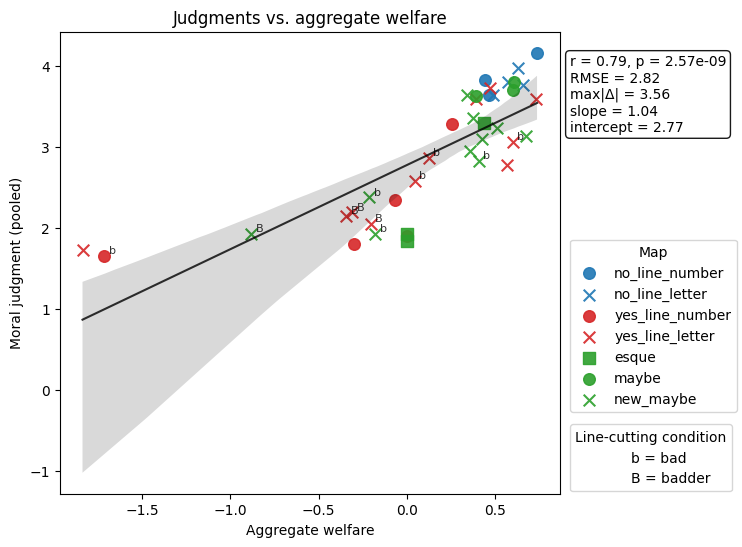

In [24]:
# Ratings vs AW
fig, ax = plot_simple_regression(
    design,
    x_col="aggregate_welfare",
    y_col="rating_mean",
    map_col="map_name",
    title="Judgments vs. aggregate welfare",
    xlabel="Aggregate welfare",
    ylabel="Moral judgment (pooled)",
    display_line_cutting_condition=True,
    fit_regression=True,
    save_path = None, # no need to save, doesn't use simulation data
)

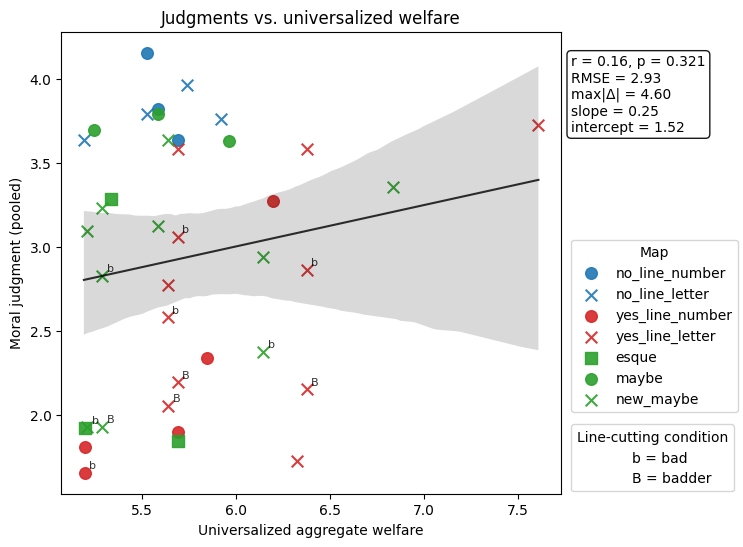

In [25]:
# Ratings vs universalized AW
fig, ax = plot_simple_regression(
    design,
    x_col="univ_aggregate_welfare",
    y_col="rating_mean",
    map_col="map_name",
    title="Judgments vs. universalized welfare",
    xlabel="Universalized aggregate welfare",
    ylabel="Moral judgment (pooled)",
    display_line_cutting_condition=True,
    fit_regression=True,
    save_path = SAVE_FOLDER / f"{RUN_PREFIX}_UW.png",
)

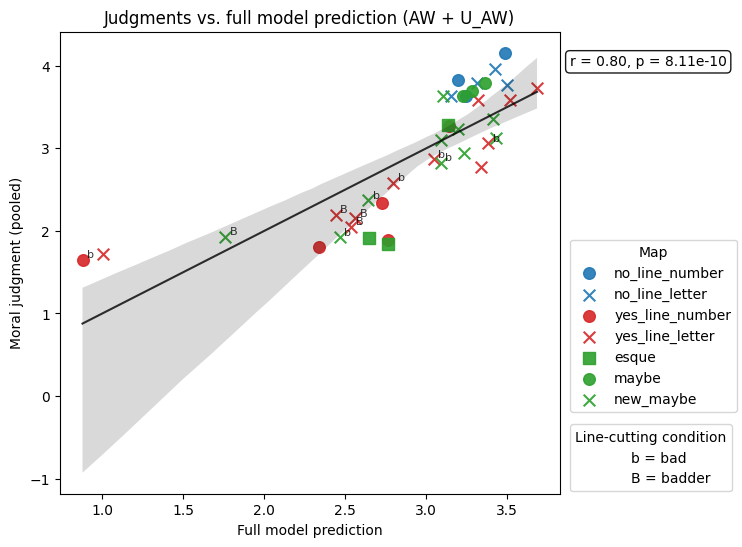

In [26]:
# Full model
row_full, m_full = fit_ols(
    design_df=design,
    predictors=["aggregate_welfare", "univ_aggregate_welfare"],
    dv="rating_mean",
    run_label=RUN_LABEL,
)
design["full_model"] = m_full.fittedvalues


# Ratings vs full model prediction (AW + U_AW)
fig, ax = plot_simple_regression(
    design,
    x_col="full_model",
    y_col="rating_mean",
    map_col="map_name",
    title="Judgments vs. full model prediction (AW + U_AW)",
    xlabel="Full model prediction",
    ylabel="Moral judgment (pooled)",
    display_line_cutting_condition=True,
    fit_regression=False,  # just correlation line
    save_path = SAVE_FOLDER / f"{RUN_PREFIX}_full.png",
)

In [27]:
# NEW: comparing in terms of simple measures of agentcompletion times

In [28]:
print("mean", univ["mean"].mean())   # average of map-level mean times
print("first", univ["first"].mean())  # average of map-level first time
print("last", univ["last"].mean())   # average of map-level last times
print ("prop_finished", univ["prop_finished"].mean())

mean nan
first nan
last nan
prop_finished 0.0


# TODO: use actual elasped time (but then need to control how I simulate stuff...)

In [32]:
from pathlib import Path
import pandas as pd
import numpy as np

def find_unfinished_runs(run_label, sim_root="../data/simulations"):
    sim_root = Path(sim_root)
    raw_dir = sim_root / run_label / "raw"

    raw_files = sorted(raw_dir.glob("*.csv"))
    if not raw_files:
        print(f"No raw files found for run_label={run_label!r} in {raw_dir}")
        return None

    records = []
    for raw_path in raw_files:
        df = pd.read_csv(raw_path)
        agent_cols = [c for c in df.columns if c.startswith("agent_")]

        # any agent == -1 in that run
        mask_unfinished = (df[agent_cols] < 0).any(axis=1)

        unfinished_df = df[mask_unfinished]
        if not unfinished_df.empty:
            map_name = raw_path.stem
            for _, row in unfinished_df.iterrows():
                records.append({
                    "map_name": map_name,
                    "run": int(row["run"]),
                    "num_unfinished": int((row[agent_cols] < 0).sum()),
                })

    if not records:
        print(f"All runs finished for run_label={run_label!r}.")
        return pd.DataFrame(columns=["map_name", "run", "num_unfinished"])

    unfinished_summary = pd.DataFrame(records)
    print(f"Found {len(unfinished_summary)} runs with unfinished agents "
          f"for run_label={run_label!r}.")
    return unfinished_summary


In [33]:
df_unfinished = find_unfinished_runs(RUN_LABEL)
df_unfinished

Found 12 runs with unfinished agents for run_label='blind_L0_new_02-10'.


,map_name,run,num_unfinished
0,yes_line_10,1,4
1,yes_line_10,2,8
2,yes_line_7,1,8
3,yes_line_7,2,8
4,yes_line_7,3,8
5,yes_line_7,4,8
6,yes_line_7,5,8
7,yes_line_8,1,4
8,yes_line_8,3,4
9,yes_line_8,4,8
